# Simulation_CLP_PID_FF


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

%config InlineBackend.figure_formats ="svg"
from package_DBR import *
from package_TCLAB import *
from package_LAB import *


## Simulation parameters

In [12]:
#Point de fonctionnement

MV0 = 50
PV0 = 54
DV0 = 50

#Parametre maniupulated value

Kp = 0.374684
T1_p = 171.145985
T2_p = 26.74464
theta_p = 12.00844


#Parmetre Disturbance Value

Kd = 0.3933681
T1_d= 161.75194
T2_d= 36.287948
theta_d= 19.570305



#IMC TUNING
gamma = 0.5
Kc,Ti,Td = IMC_Tuning(Kp, gamma, theta_p, T1_p, T2_p, 2)
print(Kc)
Kc = Kc *0.5
Ti = 0.75 *Ti



alpha = 0.9
MVMin = 0
MVMax = 100
TSim = 1700
Ts = 1
N = int(TSim/Ts) + 1


print("kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)






5.412437356773491
kc =  2.7062186783867457
Ti =  148.41796875
Td =  23.13013947108611


# Scenario

In [13]:
scenario = "CLP+FF"



# Scenario 1: CLP + FF
if scenario == "CLP+FF":
    
    ManPath = {0: True, 150: False, TSim: False} 
    MVManPath = {0: MV0+15, TSim: MV0+15} 
    
    SPPath = {0: PV0+10, 900: PV0+5, TSim: PV0+5} 
    DVPath = {0: DV0, 1100: DV0+20,  TSim: DV0+20}
    
    ActivateFF = True
    ManFF = False

# Scenario 2: CLP + no FF
if scenario == "CLP+noFF":
    ManPath = {0: True, 150: False, TSim: False} 
    MVManPath = {0: MV0+15, TSim: MV0+15} 
    
    SPPath = {0: PV0+10, 900: PV0+5, TSim: PV0+5} 
    DVPath = {0: DV0, 1100: DV0+20, TSim: DV0+20}
    
    ActivateFF = False
    ManFF = False


# Scenario 3: OLP + no FF
if scenario == "OLP+noFF":
    ManPath = {0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath = {0: PV0, TSim: PV0}
    DVPath = {0: 50, 1200: 60,TSim: 60}
    ActivateFF = False
    ManFF = True

# Scenario 4: OLP + FF
if scenario == "OLP+FF":
    ManPath ={0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath ={0: PV0, TSim: PV0}
    DVPath = {0: 50.0, 1200: 60, TSim: 60.0}
    ActivateFF = True
    ManFF = True



## Simulation 

In [14]:






t = []
MV = []

MVP = []
MVI = []
MVD = []

SP=[]
MVMan=[]
MVFF = []
Man =[]
ManFF = []

DV =[]
E = []
PV = []



MVFFDelay = []
MVFFLL_output = []

MVDelayp =[]
PV1p =[]
PV2p =[]

MVDelayd =[]
PV1d =[]
PV2d =[]



for i in range(0,N):

    t.append(i*Ts)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    

    Delay_RT(DV-DV0*np.ones_like(DV), np.max([theta_d-theta_p, 0]), Ts, MVFFDelay)
    LL_RT(MVFFDelay, -Kd/Kp, T1_p, T1_d, Ts, MVFFLL_output)

    if ActivateFF :
        LL_RT(MVFFLL_output, 1, T2_p, T2_d, Ts, MVFF)
    else :
        LL_RT(MVFFLL_output, 0, T2_p, T2_d, Ts, MVFF)

    
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t, MVMan)

    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha , Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF, PV0)

    
    Delay_RT(MV, theta_p, Ts, MVDelayp, MV0)
    FO_RT(MVDelayp, Kp, T1_p, Ts, PV1p,0)
    FO_RT(PV1p, 1, T2_p, Ts, PV2p, 0)



    Delay_RT(DV - DV0*np.ones_like(DV), theta_d, Ts, MVDelayd, 0)
    FO_RT(MVDelayd, Kd, T1_d, Ts, PV1d, 0)
    FO_RT(PV1d, 1, T2_d, Ts, PV2d, 0)

    PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)




# Import experimental Data to overlap

In [15]:
nameFile = 'CLP+FF_TCLAB_PID_FF_Test_on_2026-04-01-11h20.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Code_data/' + nameFile)



t_exp = data['t'].values
MV_exp = data['MV'].values
MVP_exp = data[' MVP'].values
MVI_exp = data[' MVI'].values
MVD_exp = data[' MVD'].values
PV_exp = data['PV'].values   
DV_exp = data['DV'].values
SP_exp = data[' SP'].values 
     

# Plot

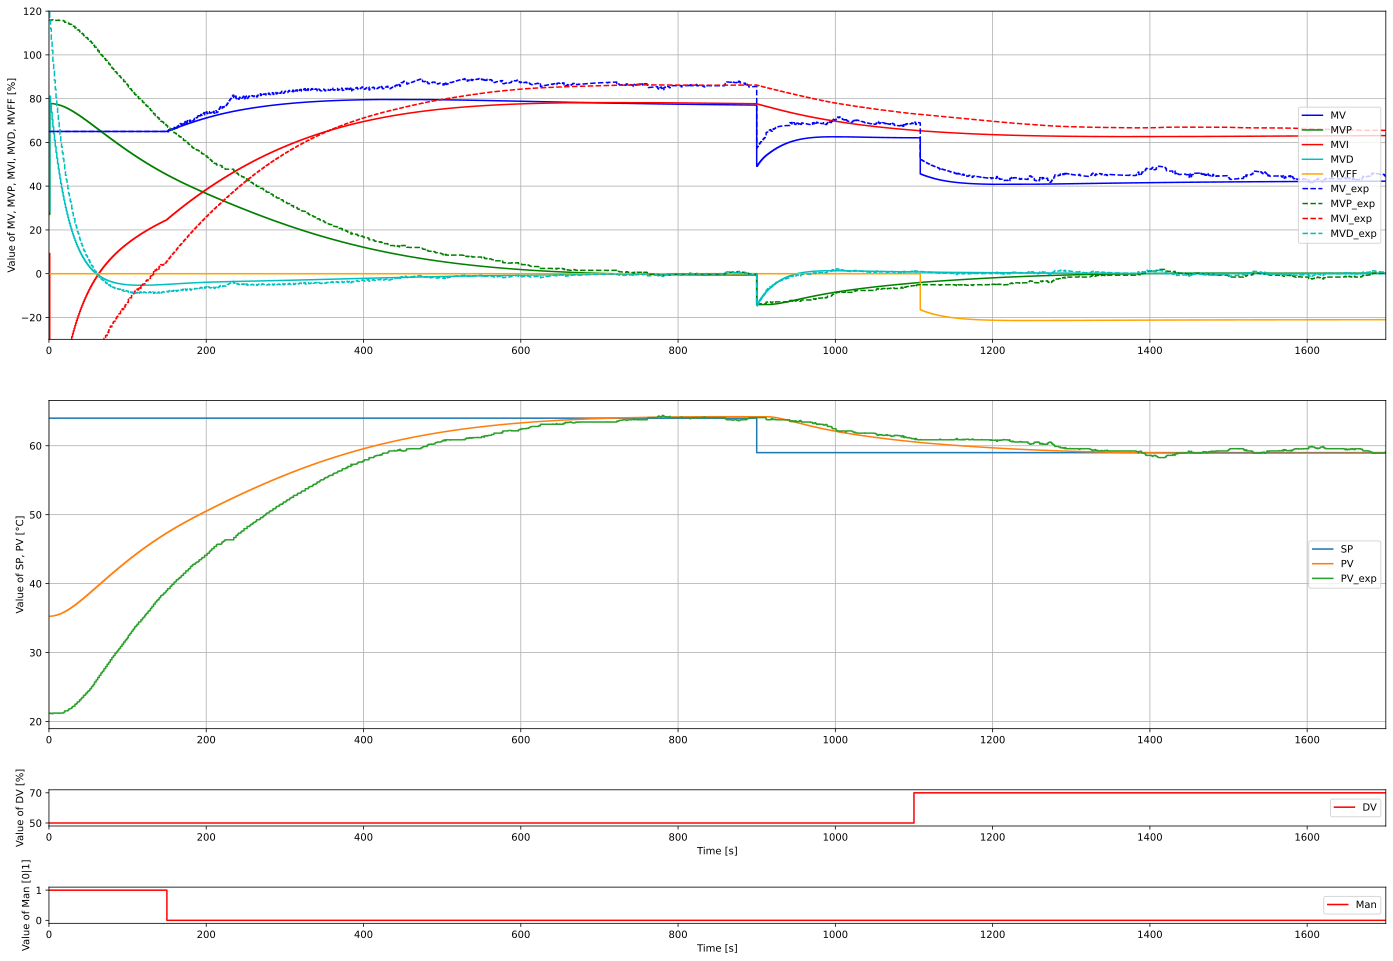

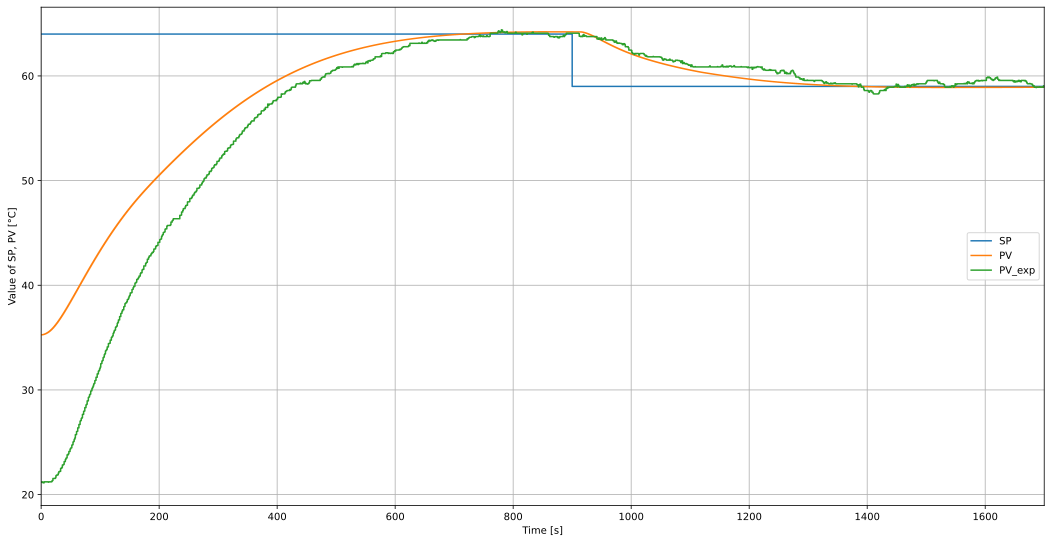

In [16]:



plt.figure(figsize = (20,14))


plt.subplot(10,1,(1,4))
plt.step(t,MV, color= "b",label='MV',where='post' )
plt.step(t,MVP, color= "g" ,label='MVP',where='post' )
plt.step(t,MVI,color= "r" ,label='MVI',where='post')
plt.step(t,MVD,color=  "c",label='MVD',where='post')
plt.step(t,MVFF,label='MVFF', color="orange",where='post')
plt.step(t_exp, MV_exp,color= "b",  label='MV_exp',where='post', linestyle="dashed" )
plt.step(t_exp,MVP_exp,color= "g",  label='MVP_exp',where='post', linestyle='dashed' )
plt.step(t_exp,MVI_exp,color= "r", label='MVI_exp',where='post', linestyle='dashed')
plt.step(t_exp,MVD_exp,color=  "c", label='MVD_exp',where='post', linestyle='dashed')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV, MVP, MVI, MVD, MVFF [%]')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.ylim([-30, 120])
plt.grid()



plt.subplot(10,1,(5,8))
plt.step(t,SP, label='SP',where='post')
plt.step(t,PV, label='PV',where='post')
plt.step(t_exp, PV_exp , label ='PV_exp', where='post')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV [°C]')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.grid()


plt.subplot(10,1,9)
plt.ylim((48,72))
plt.step(t,DV,'r-',label='DV',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of DV [%]')
plt.xlabel('Time [s]')
plt.legend(loc='right')
plt.xlim([0, TSim])    
plt.yticks((50,70))



plt.subplot(10,1,10)
plt.ylim((-0.1,1.1))
plt.step(t,Man,'r-',label='Man',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of Man [0|1]')
plt.xlabel('Time [s]')
plt.legend(loc='right')
plt.xlim([0, TSim])  

plt.tight_layout(pad=3.0) # 'pad' defines the space around the figure edges
plt.show()



plt.figure(figsize = (18,9))
plt.step(t,SP, label='SP',where='post')
plt.step(t,PV, label='PV',where='post')
plt.step(t_exp, PV_exp , label ='PV_exp', where='post')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV [°C]')
plt.xlabel('Time [s]')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.grid()
plt.show()





# Comparaison FF no FF

In [17]:
nameFile = 'TCLAB_PID_FF_Test_on_2026-03-30-14h07.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)



t_FF = data['t'].values
MV_FF = data['MV'].values
MVP_FF = data[' MVP'].values
MVI_FF = data[' MVI'].values
MVD_FF = data[' MVD'].values
PV_FF = data['PV'].values   
DV_FF = data['DV'].values
SP_FF = data[' SP'].values 


nameFile = 'TCLAB_PID_FF_Test_on_2026-03-30-14h57.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)



t_noFF = data['t'].values
MV_noFF = data['MV'].values
MVP_noFF = data[' MVP'].values
MVI_noFF = data[' MVI'].values
MVD_noFF = data[' MVD'].values
PV_noFF = data['PV'].values   
DV_noFF = data['DV'].values
SP_noFF = data[' SP'].values 





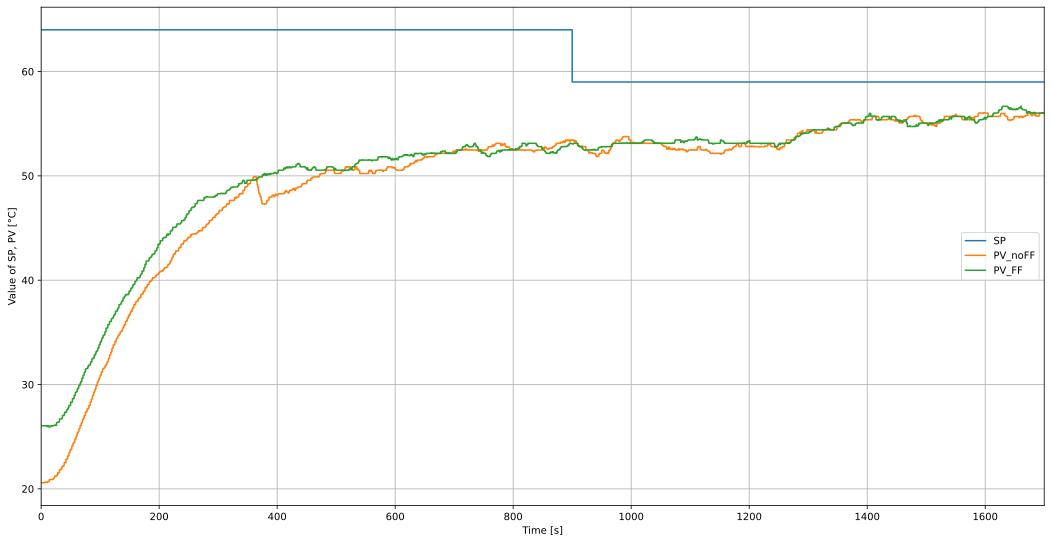

In [18]:


plt.figure(figsize = (18,9))
plt.step(t,SP, label='SP',where='post')
plt.step(t_noFF,PV_noFF, label='PV_noFF',where='post')
plt.step(t_FF, PV_FF , label ='PV_FF', where='post')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV [°C]')
plt.xlabel('Time [s]')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.grid()
plt.show()





# INFLUENCE DE GAMMA ET ALPHA

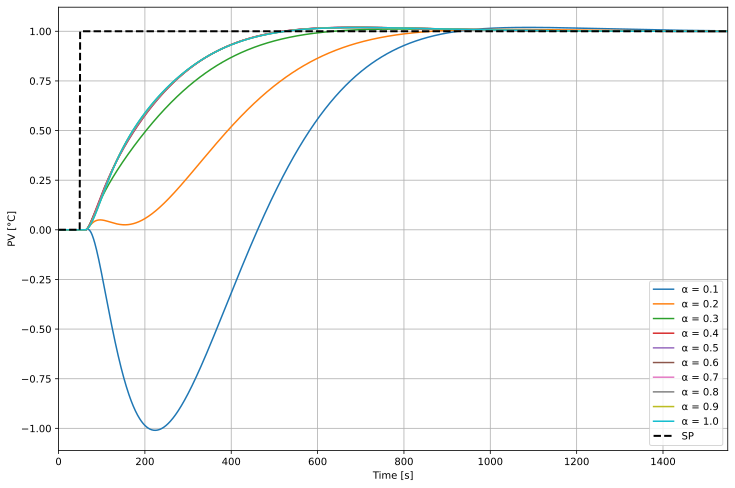

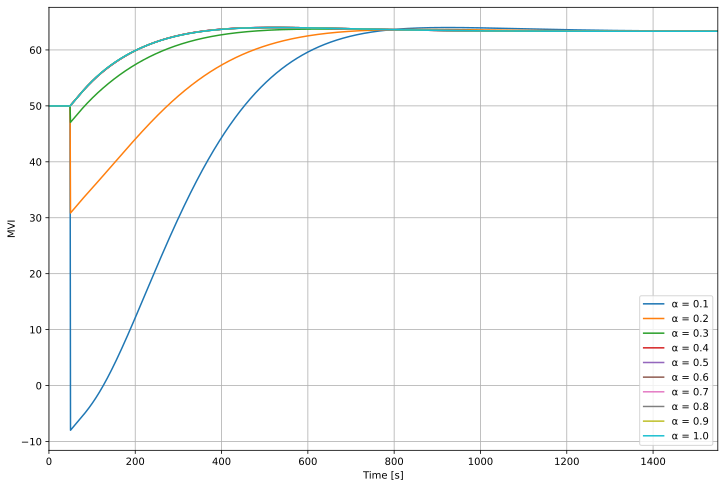

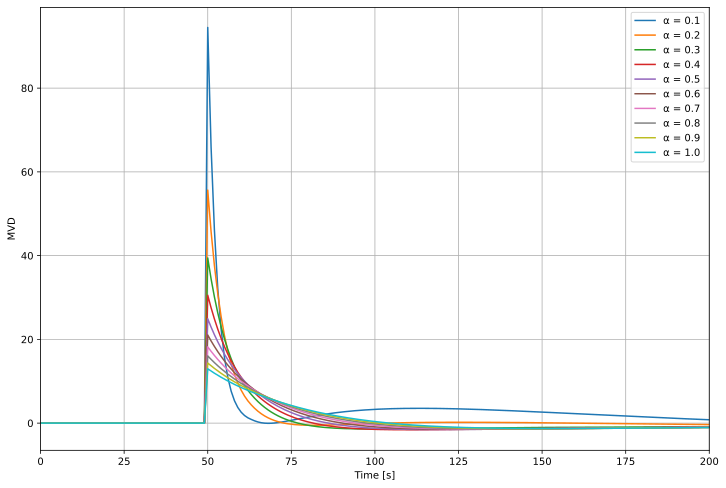

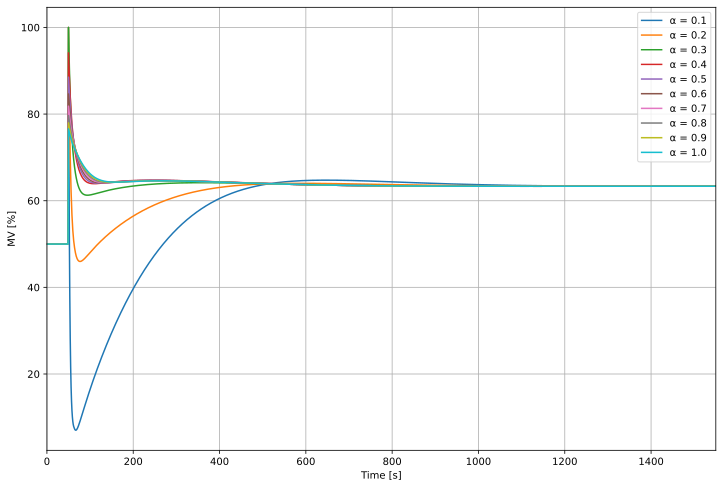

In [19]:
TSim = 3000
Ts = 1
N = int(TSim/Ts) + 1

# ============================================================
#   LISTES POUR STOCKER TOUTES LES RÉPONSES (NOUVEAUTÉ)
# ============================================================
all_PV = {}
all_SP = {}
all_MVI = {}
all_MV = {}  # Ajout de la liste pour stocker MV
all_MVD = {}

t_global = np.arange(0, TSim+1, Ts)   # temps commun (utile pour graphe complet)

# ============================================================
#   PARAMÈTRES DU PROCESSUS & PID
# ============================================================

# Paths (tu peux ajuster)
SPPath = {0: PV0, 1500: PV0 + 5, TSim: PV0 + 5}
ManPath = {0: 0, 1500: 0, TSim: 0}
ActFFPath = {0: 1, TSim: 1}
MVManPath = {0: MV0, TSim: MV0}
DVPath = {0: 50, 2500: 50, TSim: 50}

# ============================================================
#      SIMULATIONS POUR DIFFÉRENTS ALPHA
# ============================================================

alphas = np.arange(0.1, 1.01, 0.1)

plt.figure(figsize=(12, 8))

for alpha in alphas:

    # --- réinitialisation complète des variables ---
    t = []
    MV = []  # Nous allons stocker MV ici
    MVP = []
    MVI = []
    MVD = []
    MVFF = []
    PV = []
    SP = []
    Man = []
    ActFF = []
    MVMan = []
    E = []
    PV1p = []
    PV2p = []
    PV1d = []
    PV2d = []
    MVDelayd = []
    MVDelayp = []
    MVFF1 = []
    MVFF2 = []
    DVDelay = []
    DV = []

    # ============================
    #  SIMULATION BOUCLE FERMÉE
    # ============================
    for i in range(0, N):

        
        t.append(i*Ts)
        SelectPath_RT(SPPath,t,SP)
        SelectPath_RT(DVPath,t,DV)
        
    
        Delay_RT(DV-DV0*np.ones_like(DV), np.max([theta_d-theta_p, 0]), Ts, MVFFDelay)
        LL_RT(MVFFDelay, -Kd/Kp, T1_p, T1_d, Ts, MVFFLL_output)
    
        if ActivateFF :
            LL_RT(MVFFLL_output, 1, T2_p, T2_d, Ts, MVFF)
        else :
            LL_RT(MVFFLL_output, 0, T2_p, T2_d, Ts, MVFF)
    
        
        SelectPath_RT(ManPath,t,Man)
        SelectPath_RT(MVManPath,t, MVMan)
    
        PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha , Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF, PV0)
    
        
        Delay_RT(MV, theta_p, Ts, MVDelayp, MV0)
        FO_RT(MVDelayp, Kp, T1_p, Ts, PV1p,0)
        FO_RT(PV1p, 1, T2_p, Ts, PV2p, 0)
    
    
    
        Delay_RT(DV - DV0*np.ones_like(DV), theta_d, Ts, MVDelayd, 0)
        FO_RT(MVDelayd, Kd, T1_d, Ts, PV1d, 0)
        FO_RT(PV1d, 1, T2_d, Ts, PV2d, 0)
    
        PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)

    # ============================================================
    #  STOCKAGE DES RÉPONSES POUR GRAPHIQUE COMPLET
    # ============================================================
    all_PV[alpha] = PV.copy()
    all_SP[alpha] = SP.copy()
    all_MVI[alpha] = MVI.copy()
    all_MV[alpha] = MV.copy()  # Stocker MV ici
    all_MVD[alpha] = MVD.copy()

    # ============================================================
    #     NORMALISATION A PARTIR DE 1450 s (50s avant step)
    # ============================================================

    t = np.array(t)
    PV = np.array(PV)
    SP = np.array(SP)
    MVI = np.array(MVI)
    MV = np.array(MV)

    t_step = 1500  # Le step est à 1500 secondes
    idx_start = np.where(t >= (t_step - 50))[0][0]  # Commencer 50 secondes avant

    PV_initial = PV[idx_start]
    SP_final = SP[-1]

    PV_norm = (PV[idx_start:] - PV_initial) / (SP_final - PV_initial)
    SP_norm = (SP[idx_start:] - PV_initial) / (SP_final - PV_initial)
    t_norm = t[idx_start:] - (t_step - 50)  # Ajuster le temps de début

    # ======= trace la réponse normalisée =======
    plt.plot(t_norm, PV_norm, label=f'α = {alpha:.1f}')

# ---- SP normalisé sur graphe 1 ----
plt.plot(t_norm, SP_norm, 'k--', linewidth=2, label="SP")
plt.xlabel("Time [s]")
plt.ylabel("PV [°C]")
plt.grid(True)
plt.legend()
plt.xlim([0, TSim - (t_step - 50)])




plt.show()


# ============================================================
#  TRACÉ DE MVI EN FONCTION DE ALPHA (graphique supplémentaire)
# ============================================================

# Tracé du graphique de MVI non normalisé (avec zoom à partir du moment du step)
plt.figure(figsize=(12, 8))

for alpha in alphas:
    MVI_norm = np.array(all_MVI[alpha])  # Utilisation des MVI stockés
    plt.plot(t_norm, MVI_norm[idx_start:], label=f'α = {alpha:.1f}')  # Tracé de MVI à partir du step


plt.xlabel("Time [s]")
plt.ylabel("MVI")
plt.grid(True)
plt.legend()
plt.xlim([0, TSim - (t_step - 50)])  # Limiter au temps après le step
plt.show()


plt.figure(figsize=(12, 8))

for alpha in alphas:
    MVD_norm = np.array(all_MVD[alpha])  # Utilisation des MVI stockés
    plt.plot(t_norm, MVD_norm[idx_start:], label=f'α = {alpha:.1f}')  # Tracé de MVI à partir du step


plt.xlabel("Time [s]")
plt.ylabel("MVD")
plt.grid(True)
plt.legend()
plt.xlim([0, 200])  # Limiter au temps après le step
plt.show()


# ============================================================
# GRAPHIQUE COMPLET NON NORMALISÉ (MV)
# ============================================================

plt.figure(figsize=(12, 8))

for alpha in alphas:
    MV_norm = np.array(all_MV[alpha])  # Utilisation des MV stockés
    plt.plot(t_norm, MV_norm[idx_start:], label=f'α = {alpha:.1f}')  # Tracé de MV à partir du step

plt.xlabel("Time [s]")
plt.ylabel("MV [%]")  # Unité changée en fonction de MV
plt.grid(True)
plt.legend()
plt.xlim([0, TSim - (t_step - 50)])  # Limiter au temps après le step



plt.show()


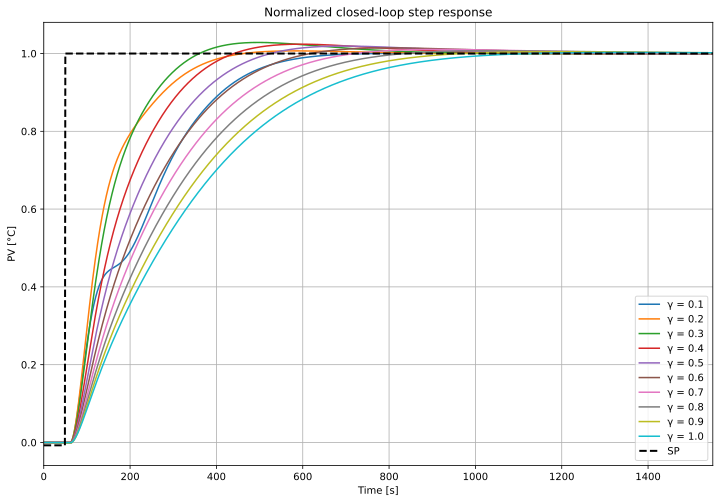

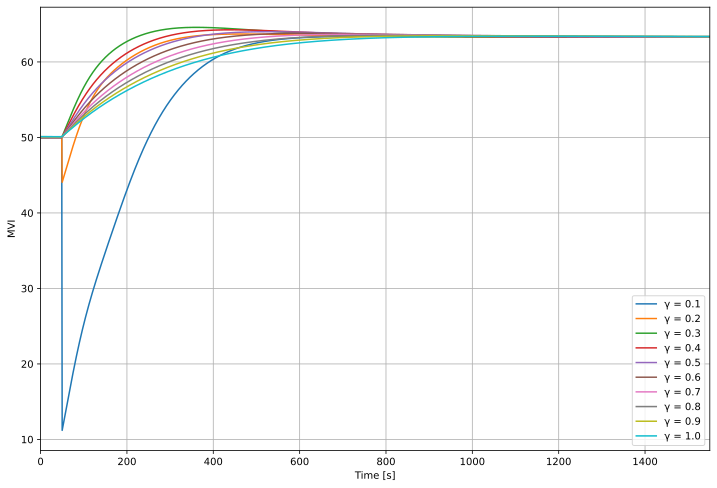

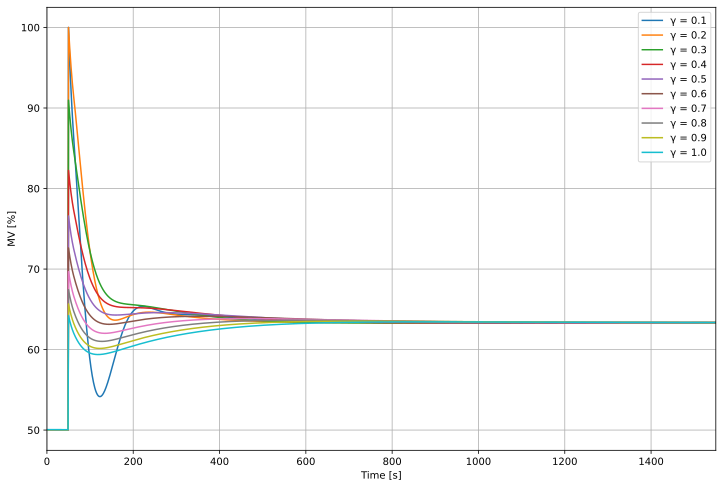

In [20]:
TSim = 3000
Ts = 1
N = int(TSim/Ts) + 1


# Valeurs de gamma à tester
gammas = np.arange(0.1, 1.01, 0.1)


SPPath = {0: PV0, 1500: PV0 + 5, 3000: PV0 + 5}
ManPath = {0: 0, 1500: 0, 3000: 0}
ActFFPath = {0: 1, 3000: 1}
MVManPath = {0: MV0, 3000: MV0}
DVPath = {0: 50, 2500: 50, 3000: 50}


# Initialisation des dictionnaires pour stocker les réponses
all_PV_gamma = {}
all_SP_gamma = {}
all_MVI_gamma = {}
all_MV_gamma = {}

# ============================================
#   SIMULATIONS POUR DIFFÉRENTS GAMMA
# ============================================

plt.figure(figsize=(12, 8))

# Boucle sur les différentes valeurs de gamma
for gamma in gammas:

    # --- Réinitialisation complète des variables ---
    t = []
    MV = []  # Nous allons stocker MV ici
    MVP = []
    MVI = []
    MVD = []
    MVFF = []
    PV = []
    SP = []
    Man = []
    ActFF = []
    MVMan = []
    E = []
    PV1p = []
    PV2p = []
    PV1d = []
    PV2d = []
    MVDelayd = []
    MVDelayp = []
    MVFF1 = []
    MVFF2 = []
    DVDelay = []
    DV = []

    # ============================
    #  SIMULATION BOUCLE FERMÉE
    # ============================
    for i in range(0, N):

        
        t.append(i*Ts)
        SelectPath_RT(SPPath,t,SP)
        SelectPath_RT(DVPath,t,DV)


        Delay_RT(DV-DV0*np.ones_like(DV), np.max([theta_d-theta_p, 0]), Ts, MVFFDelay)
        LL_RT(MVFFDelay, -Kd/Kp, T1_p, T1_d, Ts, MVFFLL_output)

        if ActivateFF :
            LL_RT(MVFFLL_output, 1, T2_p, T2_d, Ts, MVFF)
        else :
            LL_RT(MVFFLL_output, 0, T2_p, T2_d, Ts, MVFF)


        SelectPath_RT(ManPath,t,Man)
        SelectPath_RT(MVManPath,t, MVMan)


        Kc,Ti,Td = IMC_Tuning(Kp, gamma, theta_p, T1_p, T2_p, 2)
        Kc = Kc *0.5
        Ti = 0.75 *Ti



        PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha , Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF, PV0)


        Delay_RT(MV, theta_p, Ts, MVDelayp, MV0)
        FO_RT(MVDelayp, Kp, T1_p, Ts, PV1p,0)
        FO_RT(PV1p, 1, T2_p, Ts, PV2p, 0)



        Delay_RT(DV - DV0*np.ones_like(DV), theta_d, Ts, MVDelayd, 0)
        FO_RT(MVDelayd, Kd, T1_d, Ts, PV1d, 0)
        FO_RT(PV1d, 1, T2_d, Ts, PV2d, 0)


        PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)

    # ============================================================
    #  STOCKAGE DES RÉPONSES POUR GRAPHIQUE COMPLET
    # ============================================================
    all_PV_gamma[gamma] = PV.copy()
    all_SP_gamma[gamma] = SP.copy()
    all_MVI_gamma[gamma] = MVI.copy()
    all_MV_gamma[gamma] = MV.copy()  # Stocker MV ici

    # ============================================================
    #     NORMALISATION A PARTIR DE 1450 s (50s avant step)
    # ============================================================

    t = np.array(t)
    PV = np.array(PV)
    SP = np.array(SP)
    MVI = np.array(MVI)
    MV = np.array(MV)

    t_step = 1500  # Le step est à 1500 secondes
    idx_start = np.where(t >= (t_step - 50))[0][0]  # Commencer 50 secondes avant

    PV_initial = PV[idx_start]
    SP_final = SP[-1]

    PV_norm = (PV[idx_start:] - PV_initial) / (SP_final - PV_initial)
    SP_norm = (SP[idx_start:] - PV_initial) / (SP_final - PV_initial)
    t_norm = t[idx_start:] - (t_step - 50)  # Ajuster le temps de début

    # ======= trace la réponse normalisée =======
    plt.plot(t_norm, PV_norm, label=f'γ = {gamma:.1f}')

# ---- SP normalisé sur graphe 1 ----
plt.plot(t_norm, SP_norm, 'k--', linewidth=2, label="SP")
plt.title("Normalized closed-loop step response")
plt.xlabel("Time [s]")
plt.ylabel("PV [°C]")
plt.grid(True)
plt.legend()
plt.xlim([0, TSim - (t_step - 50)])

plt.show()



# ============================================================
#  TRACÉ DE MVI EN FONCTION DE GAMMA (graphique supplémentaire)
# ============================================================

# Tracé du graphique de MVI non normalisé (avec zoom à partir du moment du step)
plt.figure(figsize=(12, 8))

for gamma in gammas:
    MVI_norm = np.array(all_MVI_gamma[gamma])  # Utilisation des MVI stockés
    plt.plot(t_norm, MVI_norm[idx_start:], label=f'γ = {gamma:.1f}')  # Tracé de MVI à partir du step

plt.xlabel("Time [s]")
plt.ylabel("MVI")
plt.grid(True)
plt.legend()
plt.xlim([0, TSim - (t_step - 50)])  # Limiter au temps après le step
plt.show()

# ============================================================
# GRAPHIQUE COMPLET NON NORMALISÉ (MV)
# ============================================================

plt.figure(figsize=(12, 8))

for gamma in gammas:
    MV_norm = np.array(all_MV_gamma[gamma])  # Utilisation des MV stockés
    plt.plot(t_norm, MV_norm[idx_start:], label=f'γ = {gamma:.1f}')  # Tracé de MV à partir du step

plt.xlabel("Time [s]")
plt.ylabel("MV [%]")  # Unité changée en fonction de MV
plt.grid(True)
plt.legend()
plt.xlim([0, TSim - (t_step - 50)])  # Limiter au temps après le step



plt.show()

